# EDA and Data Preparation for TAU 2019 Acoustic Scenes

This first notebook performs the following task:
- Data loading, cleansing and train/val/test splits
- Basic descriptive statistics
- Visualizations of raw audio and log-mel spectrograms
- Visualization of MFCC-based features

It also saves the indices for train/val/test to a file so all other model notebooks use the same split.

In [ ]:
#This install all of ur required libraries make sure run this first
pip install librosa numpy pandas matplotlib sklearn --quiet

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from sklearn.model_selection import GroupShuffleSplit
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set(style='whitegrid')
SR = 22050
RANDOM_STATE = 42
TEST_SIZE = 0.2

def read_meta(path: str = 'meta.csv') -> pd.DataFrame:
    """Read TAU 2019 meta file and add a filepath column.
    Expects columns: filename, scene_label, identifier.
    """
    if not os.path.exists(path):
        raise FileNotFoundError('meta.csv not found')
    meta = pd.read_csv(path, sep='\t', quotechar='"')
    required = ['filename', 'scene_label', 'identifier']
    for c in required:
        if c not in meta:
            raise ValueError(f'Missing {c} in meta')
    meta['filepath'] = meta['filename'].apply(lambda f: os.path.join('.', f))
    return meta

def grouped_holdout(meta: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    """Grouped train/test split using the identifier column as groups."""
    x = np.arange(len(meta))
    y = meta['scene_label'].to_numpy()
    groups = meta['identifier'].to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    tr, te = next(gss.split(x, y, groups))
    return tr, te

def mfcc_stats_from_path(path: str, sr: int = SR, n_mfcc: int = 20) -> np.ndarray:
    """Compute simple MFCC statistics (mean+std per coefficient) from an audio file."""
    y, sr = librosa.load(path, sr=sr, mono=True)
    M = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mu = M.mean(axis=1)
    sd = M.std(axis=1)
    return np.concatenate([mu, sd]).astype(np.float32)

def build_mfcc_feature_matrix(paths, sr: int = SR, n_mfcc: int = 20) -> np.ndarray:
    feats = [mfcc_stats_from_path(p, sr=sr, n_mfcc=n_mfcc) for p in paths]
    return np.vstack(feats)


In [ ]:
# load data
meta = read_meta('meta.csv')
display(meta.head())

meta.info()
print('\nMissing values per column:')
print(meta.isna().sum())

# drop rows where essential fields are missing
meta = meta.dropna(subset=['scene_label', 'filepath']).reset_index(drop=True)
print(f'Number of clips after cleaning: {len(meta)}')


,filename,scene_label,identifier,source_label,filepath
0,audio/airport-lisbon-1000-40000-a.wav,airport,lisbon-1000,a,.\audio/airport-lisbon-1000-40000-a.wav
1,audio/bus-lyon-1001-40001-a.wav,bus,lyon-1001,a,.\audio/bus-lyon-1001-40001-a.wav
2,audio/shopping_mall-lisbon-1002-40002-a.wav,shopping_mall,lisbon-1002,a,.\audio/shopping_mall-lisbon-1002-40002-a.wav
3,audio/street_pedestrian-lyon-1003-40003-a.wav,street_pedestrian,lyon-1003,a,.\audio/street_pedestrian-lyon-1003-40003-a.wav
4,audio/street_pedestrian-lisbon-1004-40004-a.wav,street_pedestrian,lisbon-1004,a,.\audio/street_pedestrian-lisbon-1004-40004-a.wav


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   filename      14400 non-null  object
 1   scene_label   14400 non-null  object
 2   identifier    14400 non-null  object
 3   source_label  14400 non-null  object
 4   filepath      14400 non-null  object
dtypes: object(5)
memory usage: 562.6+ KB

Missing values per column:
filename        0
scene_label     0
identifier      0
source_label    0
filepath        0
dtype: int64
Number of clips after cleaning: 14400


In [ ]:
# train/holdout split using data from metadata
tr_idx_full, te_idx = grouped_holdout(
    meta,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
print('Initial train+val size:', len(tr_idx_full))
print('Test size:', len(te_idx))


Initial train+val size: 11656
Test size: 2744


In [ ]:
# train and validation
groups_tr = meta.loc[tr_idx_full, 'identifier'].to_numpy()
indices_tr = np.arange(len(tr_idx_full))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
sub_tr, va = next(gss.split(indices_tr, groups=groups_tr))

tr_idx = tr_idx_full[sub_tr]
va_idx = tr_idx_full[va]

print(f'Train: {len(tr_idx)} | Val: {len(va_idx)} | Test: {len(te_idx)}')


Train: 9309 | Val: 2347 | Test: 2744


In [ ]:
# save splits for training later
np.savez('splits_tau2019_grouped.npz',
         tr_idx=tr_idx,
         va_idx=va_idx,
         te_idx=te_idx)
print('Saved splits_tau2019_grouped.npz')


Saved splits_tau2019_grouped.npz


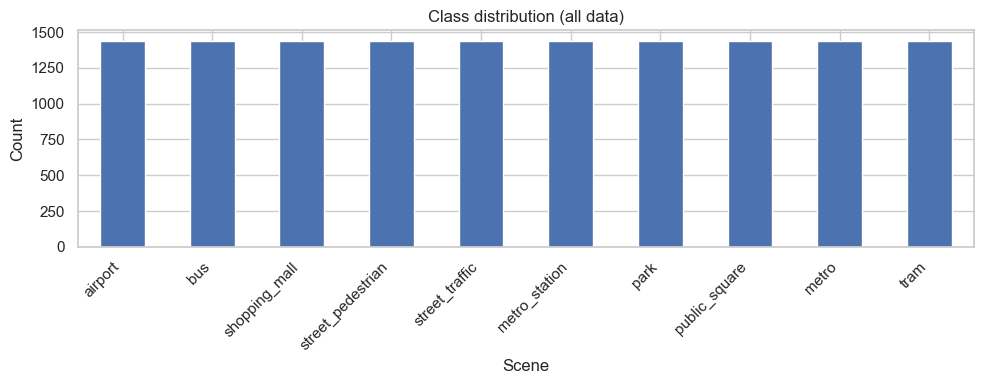

count      10.0
mean     1440.0
std         0.0
min      1440.0
25%      1440.0
50%      1440.0
75%      1440.0
max      1440.0
Name: filename, dtype: float64

In [ ]:
# class distributions
plt.figure(figsize=(10, 4))
meta['scene_label'].value_counts().plot(kind='bar')
plt.title('Class distribution (all data)')
plt.xlabel('Scene')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(meta.groupby('scene_label')['filename'].count().describe())


c:\Users\haizi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Measuring durations: 100%|██████████| 14400/14400 [04:21<00:00, 54.99it/s]


count    14400.000000
mean        10.000001
std          0.000008
min         10.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         10.000045
Name: duration_sec, dtype: float64

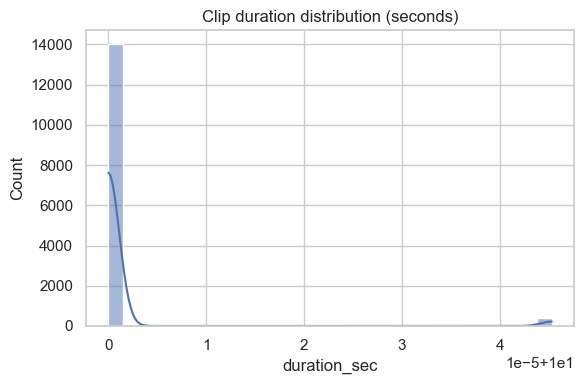

In [ ]:
# duration statistics
import tqdm.auto as tqdm_auto

durations = []
for fp in tqdm_auto.tqdm(meta['filepath'], desc='Measuring durations'):
    y, sr = librosa.load(fp, sr=SR, mono=True)
    durations.append(len(y) / sr)

meta['duration_sec'] = durations
display(meta['duration_sec'].describe())

plt.figure(figsize=(6, 4))
sns.histplot(meta['duration_sec'], bins=30, kde=True)
plt.title('Clip duration distribution')
plt.tight_layout()
plt.show()


,scene_label,filename
0,airport,audio/airport-lisbon-1000-40000-a.wav
1,bus,audio/bus-lyon-1001-40001-a.wav
2,shopping_mall,audio/shopping_mall-lisbon-1002-40002-a.wav
3,street_pedestrian,audio/street_pedestrian-lyon-1003-40003-a.wav
4,street_traffic,audio/street_traffic-prague-1006-40006-a.wav
5,metro_station,audio/metro_station-lisbon-1007-40007-a.wav
6,park,audio/park-lyon-1012-40014-a.wav
7,public_square,audio/public_square-milan-1014-40017-a.wav
8,metro,audio/metro-prague-1016-40020-a.wav
9,tram,audio/tram-lisbon-1035-40042-a.wav


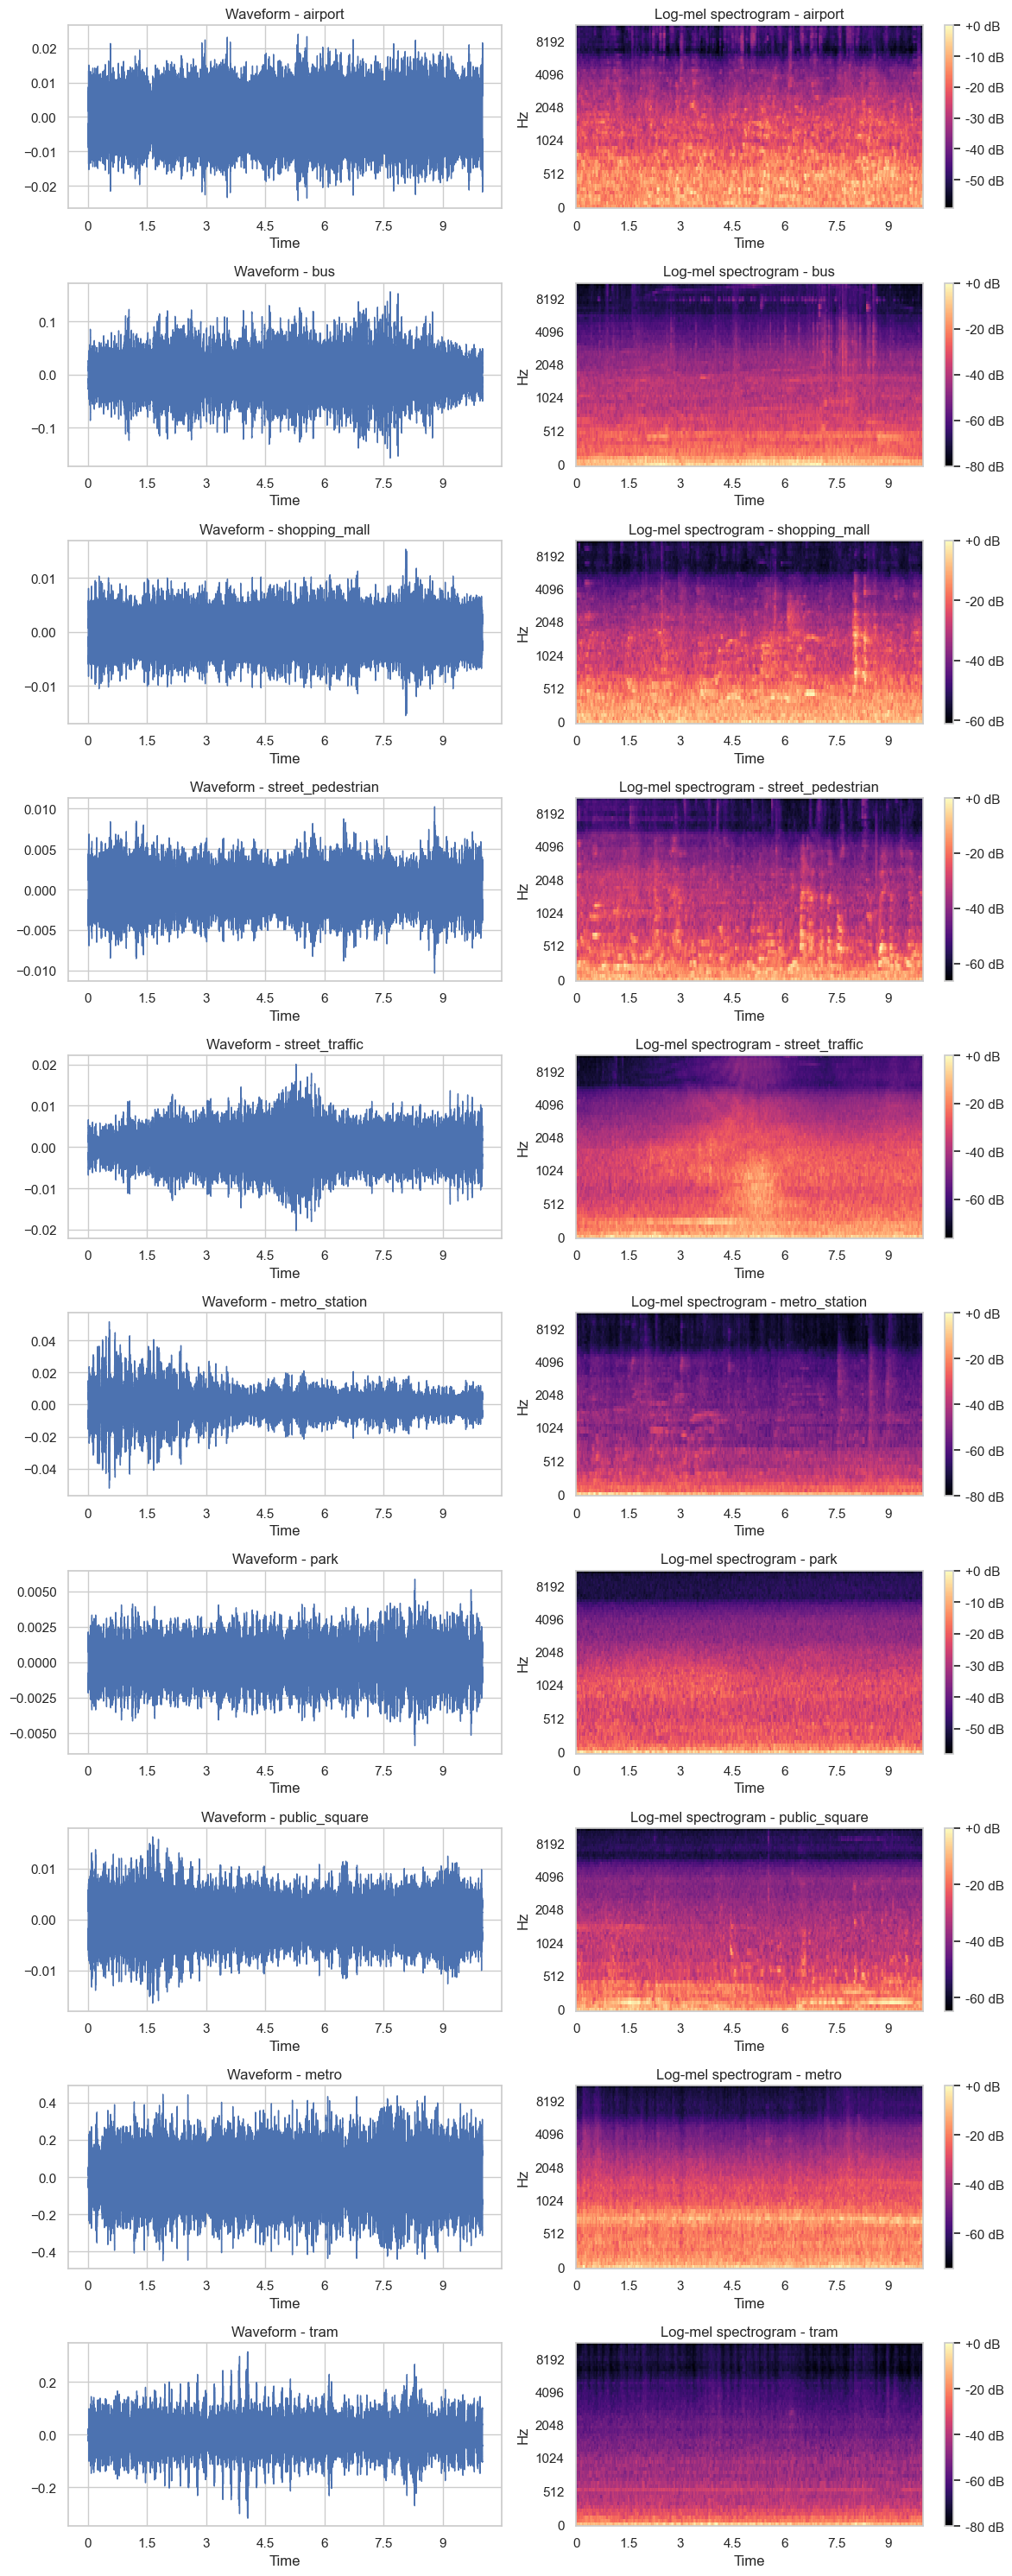

In [ ]:
# example waveforms and spectrograms
example_rows = meta.groupby('scene_label').head(1).reset_index(drop=True)
display(example_rows[['scene_label', 'filename']])

n_examples = len(example_rows)
plt.figure(figsize=(12, 3 * n_examples))

for i, (_, row) in enumerate(example_rows.iterrows(), 1):
    y, sr = librosa.load(row['filepath'], sr=SR, mono=True)
    plt.subplot(n_examples, 2, 2 * i - 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {row['scene_label']}")

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, fmin=50, fmax=None)
    logS = librosa.power_to_db(S, ref=np.max)
    plt.subplot(n_examples, 2, 2 * i)
    librosa.display.specshow(logS, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Log-mel spectrogram - {row['scene_label']}")

plt.tight_layout()
plt.show()


MFCC feature matrix shape: (14400, 40)


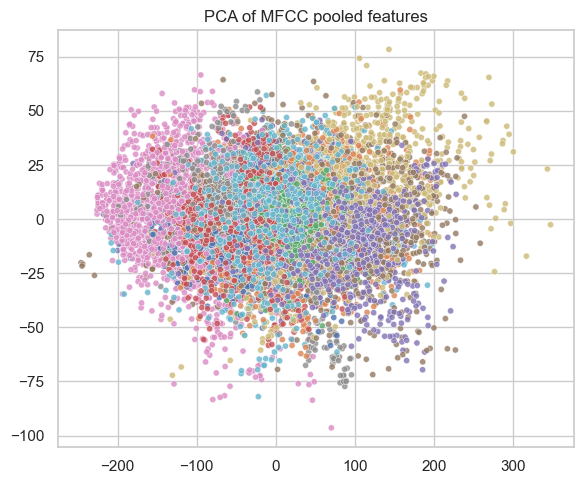

In [ ]:
# visualization using MFCC pooled statistics
filepaths = meta['filepath'].tolist()
X_mfcc = build_mfcc_feature_matrix(filepaths, sr=SR, n_mfcc=20)
print('MFCC feature matrix shape:', X_mfcc.shape)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_mfcc)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],hue=meta['scene_label'], s=20, alpha=0.8, legend=False)
plt.title('PCA of MFCC pooled features')
plt.tight_layout()
plt.show()


TODO IN REPORT:classes are balanced or imbalanced
any interesting duration statistics
how well classes appear to separate in the PCA visualization
initial expectations for which classes may be harder to classify and why.
